In [1]:
import pandas as pd 
import numpy as np  

import os

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import ModelCheckpoint
from keras.utils import to_categorical

tf.config.set_visible_devices([], 'GPU')

2023-06-19 15:34:47.452440: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Load the data.

In [2]:
data = pd.read_hdf("../../TC_Antigen_encoding-main/initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")
MARKERS = data.columns
# ANTIGENS = ['V4', 'T4', 'Q4', 'A2', 'N4']  # Only focus on the strong markers. 
ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']
TIMES = [4.0, 12.0, 24.0, 30.0, 36.0, 48.0, 60.0, 72.0]
TEST_PROPORTION = 0.25

In [3]:
# Filter the data to the strong antigens, first repliate, OT-1 cells, high concentration, and later. 
df = data.loc[(data.index.get_level_values('CellType') == 'OT-1') & 
                       #(data.index.get_level_values('Replicate') == '1') &
                       (data.index.get_level_values('Time') >= 4.0) & # [4.0, 12.0, 24.0, 30.0, 36.0, 48.0, 60.0, 72.0]
                       (data.index.get_level_values('Peptide').isin(ANTIGENS))
                    ]

group_size = 20

def avg(group): 
    group['GroupNumber'] = np.array(range(len(group.index))) // group_size
    res = group.groupby('GroupNumber').mean()
    return res

averaged_df = df.groupby(['Peptide', 'Time']).apply(avg)

# Normalize the data. 
# df = pd.DataFrame(StandardScaler().fit_transform(df), columns=df.columns, index=df.index) 
averaged_df = pd.DataFrame(StandardScaler().fit_transform(averaged_df), columns=averaged_df.columns, index=averaged_df.index) 

In [4]:
antigen = list(averaged_df.index.get_level_values('Peptide'))
time = list(averaged_df.index.get_level_values('Time'))

In [5]:
X = np.array(averaged_df.values)
y = np.array(list(map(lambda x: ANTIGENS.index(x), antigen)))
y = to_categorical(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_PROPORTION, random_state=42)

# Setup the autoencoder model. 

In [6]:
autoencoder = Sequential([
    tf.keras.Input(shape=(len(MARKERS),)),
    layers.Dense(15, activation='elu'),
    layers.Dense(10, activation='softsign'),
    layers.Dense(5, activation='swish'),
    layers.Dense(2, activation='linear', name="Bottleneck"), # The bottleneck. 
    layers.Dense(5, activation='selu'), 
    layers.Dense(len(ANTIGENS), activation='softmax', name="Output") # Predicting the input. 
])

In [7]:
CHECKPOINT_PATH = "./cp-1992.ckpt"
checkpoint_dir = os.path.dirname(CHECKPOINT_PATH)

autoencoder.load_weights(CHECKPOINT_PATH)
autoencoder.build()
autoencoder.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 15)                405       
                                                                 
 dense_1 (Dense)             (None, 10)                160       
                                                                 
 dense_2 (Dense)             (None, 5)                 55        
                                                                 
 Bottleneck (Dense)          (None, 2)                 12        
                                                                 
 dense_3 (Dense)             (None, 5)                 15        
                                                                 
 Output (Dense)              (None, 8)                 48        
                                                                 
Total params: 695
Trainable params: 695
Non-trainable pa

# Get the embedding from the bottleneck layer. 

In [8]:
train_time, test_time = train_test_split(time, test_size=TEST_PROPORTION, random_state=42)
train_antigen, test_antigen = train_test_split(antigen, test_size=TEST_PROPORTION, random_state=42)

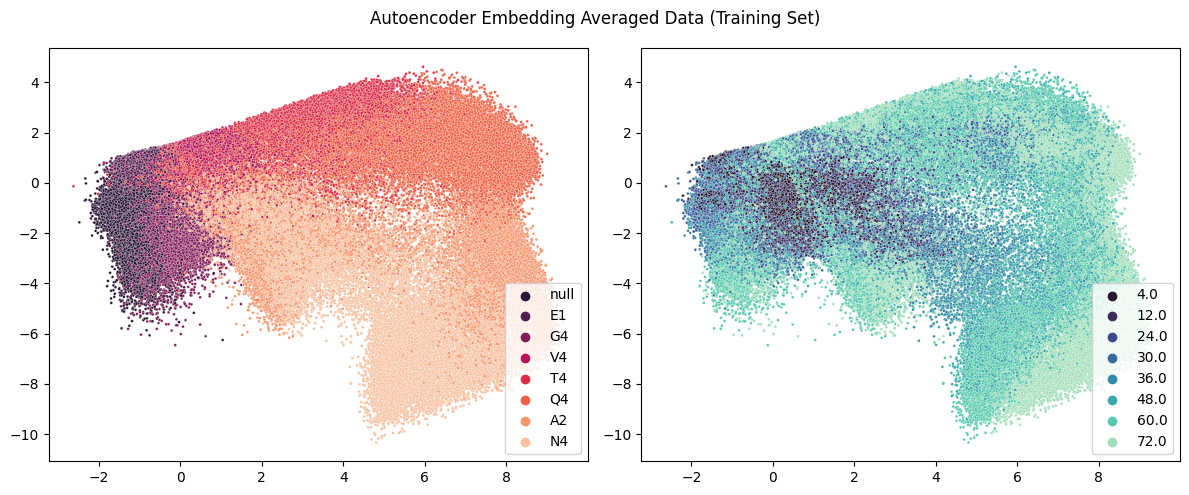

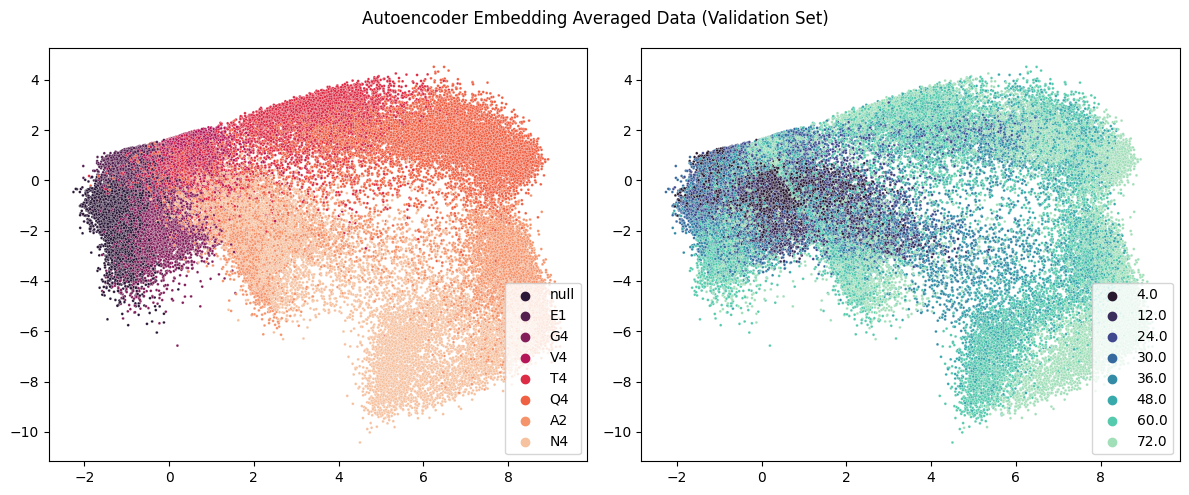

In [9]:
extractor = Model(inputs=autoencoder.inputs,
                        outputs=autoencoder.get_layer("Bottleneck").output)

embedding = np.array( extractor(X_test) )
embedding_train = np.array( extractor(X_train) )
# Create a figure with two subplots


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    x=embedding_train[:,0], 
    y=embedding_train[:,1], 
    hue=pd.Categorical(train_antigen), 
    palette="rocket", 
    hue_order=ANTIGENS,
    s=4, 
    ax=ax1
)

sns.scatterplot(
    x=embedding_train[:,0], 
    y=embedding_train[:,1], 
    hue=pd.Categorical(train_time), 
    palette="mako", 
    s=4, 
    ax=ax2
)

fig.suptitle("Autoencoder Embedding Averaged Data (Training Set)")
ax1.legend(loc="lower right")
ax2.legend(loc="lower right")
plt.tight_layout()



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    x=embedding[:,0], 
    y=embedding[:,1], 
    hue=pd.Categorical(test_antigen), 
    palette="rocket", 
    hue_order=ANTIGENS,
    s=4, 
    ax=ax1
)

sns.scatterplot(
    x=embedding[:,0], 
    y=embedding[:,1], 
    hue=pd.Categorical(test_time), 
    palette="mako", 
    s=4, 
    ax=ax2
)

fig.suptitle("Autoencoder Embedding Averaged Data (Validation Set)")
ax1.legend(loc="lower right")
ax2.legend(loc="lower right")
plt.tight_layout()

In [87]:
import hvplot.pandas

df = pd.DataFrame({
    'x': embedding[:, 0],
    'y': embedding[:, 1],
    'antigen': pd.Categorical(test_antigen)
})


df.hvplot.scatter(x='x', y='y', by='antigen', width=800, height=500, datashade=True, title="Autoencoder Embedding Averaged Data (Validation Set)")

BokehModel(combine_events=True, render_bundle={'docs_json': {'a632dd77-297a-4d27-b44b-28a0a1e2875d': {'version…

:DynamicMap   []
   :RGB   [x,y]   (R,G,B,A)

In [86]:
df = pd.DataFrame({
    'x': embedding_train[:, 0],
    'y': embedding_train[:, 1],
    'antigen': pd.Categorical(train_antigen)
})


df.hvplot.scatter(x='x', y='y', by='antigen', width=800, height=500, datashade=True, title="Autoencoder Embedding Averaged Data (Training Set)")

BokehModel(combine_events=True, render_bundle={'docs_json': {'d4e904bd-bed8-4a62-9be4-a7e94c810406': {'version…

:DynamicMap   []
   :RGB   [x,y]   (R,G,B,A)

Task exception was never retrieved
future: <Task finished name='Task-379' coro=<Callback.process_on_change() done, defined at /Users/sean/Documents/FrancoisLab/venv/lib/python3.9/site-packages/holoviews/plotting/bokeh/callbacks.py:322> exception=UnsetValueError("figure(id='p7554', ...).inner_height doesn't have a value set")>
Traceback (most recent call last):
  File "/Users/sean/Documents/FrancoisLab/venv/lib/python3.9/site-packages/holoviews/plotting/bokeh/callbacks.py", line 340, in process_on_change
    msg[attr] = self.resolve_attr_spec(path, cb_obj)
  File "/Users/sean/Documents/FrancoisLab/venv/lib/python3.9/site-packages/holoviews/plotting/bokeh/callbacks.py", line 248, in resolve_attr_spec
    resolved = getattr(resolved, p, None)
  File "/Users/sean/Documents/FrancoisLab/venv/lib/python3.9/site-packages/bokeh/core/property/descriptors.py", line 283, in __get__
    raise UnsetValueError(f"{obj}.{self.name} doesn't have a value set")
bokeh.core.property.descriptors.UnsetValueEr

# Now we can color the scatter plot by different values of markers. 

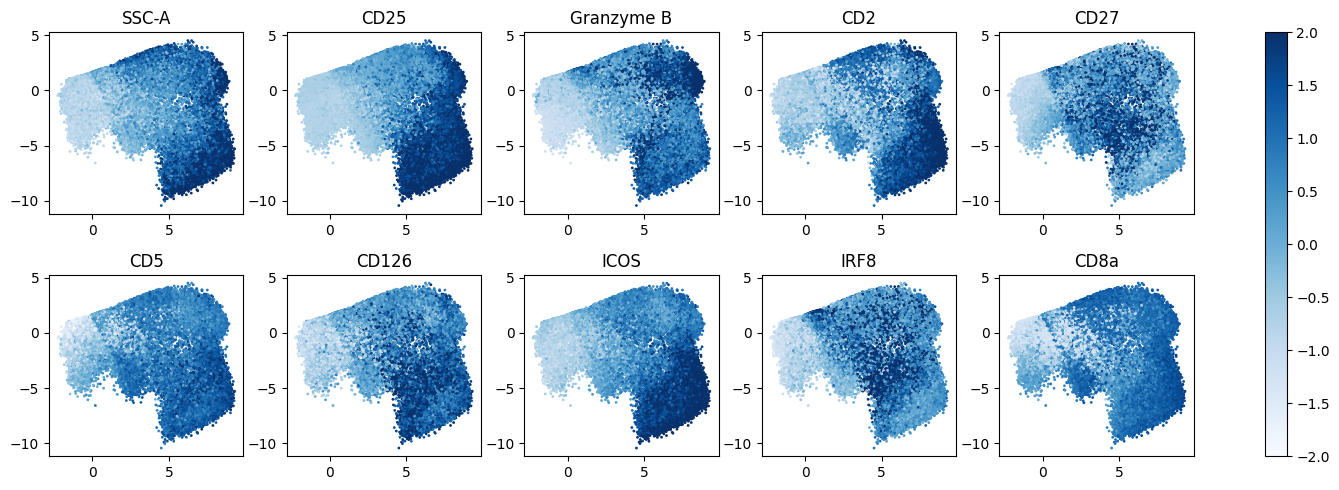

In [11]:
# Plot the top ten markers identified from before. 
MARKERS = ['SSC-A','CD25','Granzyme B','CD2','CD27','CD5','CD126','ICOS','IRF8','CD8a']

fig, axs = plt.subplots(2, 5, figsize=(15,5))

axs = axs.flatten()

vmin = -2 * np.std(averaged_df.values)
vmax = 2 * np.std(averaged_df.values)

for i, marker in enumerate(MARKERS):
    train_marker, test_marker = train_test_split(averaged_df[marker], test_size=TEST_PROPORTION, random_state=42)

    sc = axs[i].scatter(
        x=embedding[:,0], 
        y=embedding[:,1], 
        c=test_marker, 
        cmap='Blues', 
        s=1, 
        vmin=vmin,
        vmax=vmax
    )

    axs[i].set_title(marker)

plt.tight_layout()

# cax = fig.add_axes([0.92, 0.1, 0.02, 0.8])
plt.colorbar(sc, ax=axs.ravel().tolist())

# Now we create a confusion matrix. 

In [12]:
from sklearn.metrics import confusion_matrix

y_pred = np.argmax( autoencoder(X_test), axis=1 )
y_true = np.argmax(y_test, axis=1) 

cm = confusion_matrix(y_true, y_pred)

cm

array([[7053,  366, 1365,   11,   20,    2,    6,    0],
       [ 507, 4922,  190,  995,   91,    0,    0,    0],
       [2340,  361, 5090,   86,  144,   23,  201,   14],
       [  90, 1518,  256, 5227, 1394,   26,   27,   75],
       [ 112,  554,  313, 3419, 4960,  891,  162,  219],
       [  45,  594,  203,  859, 1277, 8210,  243,  148],
       [   1,    0,  176,    4,  163,  117, 6738, 3429],
       [   3,    1,  151,    8,  412,   75, 2065, 8231]])

[Text(0, 0.5, 'null'),
 Text(0, 1.5, 'E1'),
 Text(0, 2.5, 'G4'),
 Text(0, 3.5, 'V4'),
 Text(0, 4.5, 'T4'),
 Text(0, 5.5, 'Q4'),
 Text(0, 6.5, 'A2'),
 Text(0, 7.5, 'N4')]

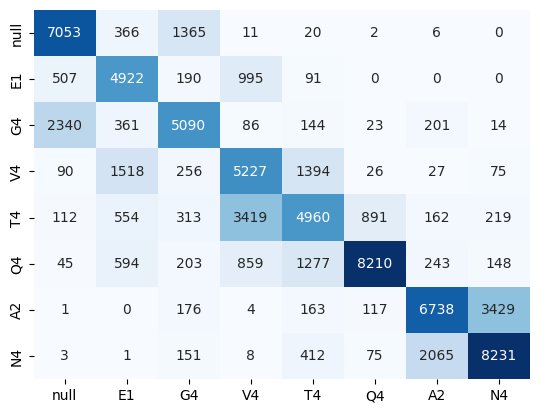

In [13]:
# Create a figure and axes
fig, ax = plt.subplots()

# Create the heatmap using seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)

# Set labels for the x and y axes
ax.set_xticklabels(ANTIGENS)
ax.set_yticklabels(ANTIGENS)